In [1]:
!pip install -q langgraph langchain langchain-groq groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.6 MB/s eta 0:00:00


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
import os

In [3]:
os.environ["GROQ_API_KEY"] = "gsk_xxxxxxxxxxxxxxxxx"

In [4]:
from typing import TypedDict

class LogisticsState(TypedDict):
    shipment_info: str
    alert_analysis: str
    route_plan: str
    decision: str
    execution_status: str

In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.2
)

In [6]:
#Agent  1 -Alert Analysis Agent
def alert_analysis_agent(state: LogisticsState):

    prompt = f"""
You are an AI Logistics Alert Analysis Agent.

Analyze the shipment delay.

Shipment Information:

{state['shipment_info']}

Identify:

1. Delay reason
2. Severity
3. Immediate action required
"""

    response = llm.invoke(prompt)

    state["alert_analysis"] = response.content

    return state

In [14]:
sample_state = {
    "shipment_info": """
Shipment ID: SHP001
Source: Mumbai
Destination: Pune
Delay: 3 Hours
Reason: Heavy Traffic
Cargo: Temperature-sensitive vaccines
""",

    "alert_analysis": "",
    "route_plan": "",
    "decision": "",
    "execution_status": ""
}

In [16]:
#Test agent 1
print(sample_state["alert_analysis"])

**Logistics Alert Analysis Report**

**Shipment ID:** SHP001
**Source:** Mumbai
**Destination:** Pune
**Delay:** 3 Hours
**Reason:** Heavy Traffic
**Cargo:** Temperature-sensitive vaccines

**Analysis:**

1. **Delay Reason:** The primary reason for the shipment delay is **Heavy Traffic**. This is a common issue in urban areas, particularly during peak hours or due to road construction.
2. **Severity:** The delay of 3 hours is considered **Moderate**. While it may not be catastrophic, it can still impact the timely delivery of temperature-sensitive vaccines, which require strict temperature control to maintain their potency.
3. **Immediate Action Required:**
	* **Re-route the shipment:** Consider re-routing the shipment via alternative routes to avoid heavy traffic areas.
	* **Temperature monitoring:** Ensure that the temperature-sensitive vaccines are being maintained within the required temperature range during the delay.
	* **Communication:** Inform the consignee and relevant stakeho

In [7]:
#Agent  2- Route Planning Agent
def route_planning_agent(state: LogisticsState):

    prompt = f"""
You are an AI Route Planning Agent.

Based on the shipment information and alert analysis, suggest the best alternative routes.

Shipment Information:
{state['shipment_info']}

Alert Analysis:
{state['alert_analysis']}

Provide:

1. Three possible routes
2. ETA for each route
3. Estimated transportation cost
4. Advantages and disadvantages of each route
5. Recommend the best route
"""

    response = llm.invoke(prompt)

    state["route_plan"] = response.content

    return state

In [8]:
#Test agent  2
sample_state = {
    "shipment_info": """
Shipment ID: SHP001
Source: Mumbai
Destination: Pune
Delay: 3 Hours
Reason: Heavy Traffic
Cargo: Temperature-sensitive vaccines
""",
    "alert_analysis": "",
    "route_plan": "",
    "decision": "",
    "execution_status": ""
}

sample_state = alert_analysis_agent(sample_state)
sample_state = route_planning_agent(sample_state)

print(sample_state["route_plan"])

**Alternative Route Options for Shipment SHP001**

Based on the shipment information and alert analysis, I have identified three possible routes to mitigate the delay and ensure the safe delivery of temperature-sensitive vaccines from Mumbai to Pune.

**Route 1: Mumbai - Nashik - Pune (NH 3)**

* **Distance:** 340 km
* **ETA:** 5 hours 30 minutes (assuming normal traffic conditions)
* **Estimated Transportation Cost:** ₹ 12,500 (approximately $165 USD)
* **Advantages:**
	+ Avoids heavy traffic in Mumbai
	+ Uses a major national highway (NH 3) for a smoother journey
	+ Has multiple fuel stations and rest stops along the route
* **Disadvantages:**
	+ May involve a longer journey time compared to other routes
	+ Requires careful monitoring of temperature-sensitive vaccines during transit

**Route 2: Mumbai - Kalyan - Ahmednagar - Pune (NH 48)**

* **Distance:** 320 km
* **ETA:** 5 hours 15 minutes (assuming normal traffic conditions)
* **Estimated Transportation Cost:** ₹ 11,500 (approxim

In [9]:
#Agent 3 -Decision Agent
def decision_agent(state: LogisticsState):

    prompt = f"""
You are an AI Decision Agent.

Evaluate the proposed routes.

Shipment Information:
{state['shipment_info']}

Available Routes:
{state['route_plan']}

Choose ONLY ONE route.

Explain:

- Why it is the best
- Estimated savings
- Expected delivery time
- Risk level
"""

    response = llm.invoke(prompt)

    state["decision"] = response.content

    return state

In [10]:
#Test agent 3
sample_state = decision_agent(sample_state)

print(sample_state["decision"])

**Recommended Route:** Mumbai - Thane - Bhiwandi - Pune (NH 3)

**Why it is the best:**

Route 3 is the best option due to its shortest journey time, lowest estimated transportation cost, and ability to avoid heavy traffic in Mumbai. This route offers a balance between speed, cost, and reliability, making it the most suitable choice for shipment SHP001.

**Estimated Savings:**

Compared to the original route, Route 3 offers estimated savings of:

- ₹ 2,000 (approximately $26 USD) compared to Route 1
- ₹ 1,000 (approximately $13 USD) compared to Route 2

**Expected Delivery Time:**

The expected delivery time for Route 3 is 4 hours 45 minutes, assuming normal traffic conditions. This is a significant improvement over the original route, which was delayed by 3 hours due to heavy traffic.

**Risk Level:**

The risk level for Route 3 is moderate. While it avoids heavy traffic in Mumbai, it still requires careful monitoring of temperature-sensitive vaccines during transit. However, the shor

In [11]:
#Agent  4 -Execution Agent
def execution_agent(state: LogisticsState):

    prompt = f"""
You are an AI Logistics Execution Agent.

Using the final decision below:

{state['decision']}

Generate an execution report.

Include:

- Selected Route
- Updated ETA
- Driver Notification
- Warehouse Notification
- Customer Notification
- Shipment Status
"""

    response = llm.invoke(prompt)

    state["execution_status"] = response.content

    return state

In [12]:
#Test Agent 4
sample_state = execution_agent(sample_state)

print(sample_state["execution_status"])

**Logistics Execution Report**

**Shipment ID:** SHP001
**Date:** 15 July 2026
**Time:** 10:00 AM

**Selected Route:** Mumbai - Thane - Bhiwandi - Pune (NH 3)

**Updated ETA:** 4 hours 45 minutes from the current time (10:00 AM), with an estimated arrival time of 2:45 PM.

**Driver Notification:**

- Driver Name: Ramesh
- Driver Contact: 9876543210
- Route Briefing: Driver Ramesh has been notified of the updated route and ETA. He has been instructed to monitor temperature-sensitive vaccines during transit and to use real-time traffic updates to minimize delays.
- Vehicle Details: Vehicle registration number MH-01-AB-1234, Vehicle type: Truck, Vehicle capacity: 10 tons

**Warehouse Notification:**

- Warehouse Name: Mumbai Warehouse
- Warehouse Contact: 9876543210
- Shipment Details: The shipment has been updated with the new route and ETA. The warehouse staff has been notified to prepare the shipment for dispatch.
- Shipment Status: Ready for dispatch

**Customer Notification:**

- Cus

In [17]:
## Step 14: Build the LangGraph Workflow
from langgraph.graph import StateGraph, END

In [18]:
workflow = StateGraph(LogisticsState)

In [19]:
workflow.add_node("alert_analysis", alert_analysis_agent)

workflow.add_node("route_planning", route_planning_agent)

workflow.add_node("decision", decision_agent)

workflow.add_node("execution", execution_agent)

In [21]:
workflow.set_entry_point("alert_analysis")

In [20]:
workflow.set_entry_point("alert_analysis")

workflow.add_edge("alert_analysis", "route_planning")

workflow.add_edge("route_planning", "decision")

workflow.add_edge("decision", "execution")

workflow.add_edge("execution", END)

In [22]:
graph = workflow.compile()

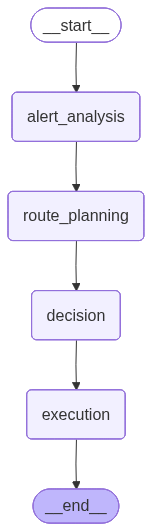

In [28]:
## Step 17: Compile the LangGraph WorkflowCompile the workflow into an executable graph.
graph


In [29]:
## Step 19: Execute the Multi-Agent Workflow ,Run the compiled LangGraph workflow,Each agent executes sequentially and updates the shared workflow state.
result = graph.invoke(sample_state)

In [26]:
## Step 20: Display Final Results
print(result["alert_analysis"])
print(result["route_plan"])
print(result["decision"])
print(result["execution_status"])

**Shipment Delay Analysis Report**

**Shipment Information:**

- Shipment ID: SHP001
- Source: Mumbai
- Destination: Pune
- Delay: 3 Hours
- Reason: Heavy Traffic
- Cargo: Temperature-sensitive vaccines

**Analysis:**

1. **Delay Reason:** The primary reason for the delay is Heavy Traffic, which is a common issue in urban areas like Mumbai.

2. **Severity:** The severity of the delay is moderate. A 3-hour delay may not be critical for most shipments, but it's crucial for temperature-sensitive vaccines, as prolonged exposure to extreme temperatures can compromise their efficacy.

3. **Immediate Action Required:**

- **Temperature Monitoring:** Immediately check the shipment's temperature logs to ensure that the vaccines have not been exposed to extreme temperatures during the delay. If the temperature has been compromised, take necessary actions to mitigate the damage.
- **Reroute or Expedite:** Consider rerouting the shipment via an alternative route or expediting it to minimize furthe

In [27]:
print("=" * 80)
print("🚚 AI LOGISTICS MULTI-AGENT WORKFLOW")
print("=" * 80)

print("\n📍 ALERT ANALYSIS")
print(result["alert_analysis"])

print("\n🛣️ ROUTE PLANNING")
print(result["route_plan"])

print("\n✅ DECISION")
print(result["decision"])

print("\n📦 EXECUTION REPORT")
print(result["execution_status"])

🚚 AI LOGISTICS MULTI-AGENT WORKFLOW

📍 ALERT ANALYSIS
**Shipment Delay Analysis Report**

**Shipment Information:**

- Shipment ID: SHP001
- Source: Mumbai
- Destination: Pune
- Delay: 3 Hours
- Reason: Heavy Traffic
- Cargo: Temperature-sensitive vaccines

**Analysis:**

1. **Delay Reason:** The primary reason for the delay is Heavy Traffic, which is a common issue in urban areas like Mumbai.

2. **Severity:** The severity of the delay is moderate. A 3-hour delay may not be critical for most shipments, but it's crucial for temperature-sensitive vaccines, as prolonged exposure to extreme temperatures can compromise their efficacy.

3. **Immediate Action Required:**

- **Temperature Monitoring:** Immediately check the shipment's temperature logs to ensure that the vaccines have not been exposed to extreme temperatures during the delay. If the temperature has been compromised, take necessary actions to mitigate the damage.
- **Reroute or Expedite:** Consider rerouting the shipment via an